       TRAFFIC VOLUME PREDICTION PROJECT

Loading dataset...

Dataset loaded successfully!
Number of rows    : 48204
Number of columns : 9

First 5 rows:


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918



MISSING VALUE CHECK
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

Preprocessing data...

Data preprocessing completed!
Rows after preprocessing: 48204


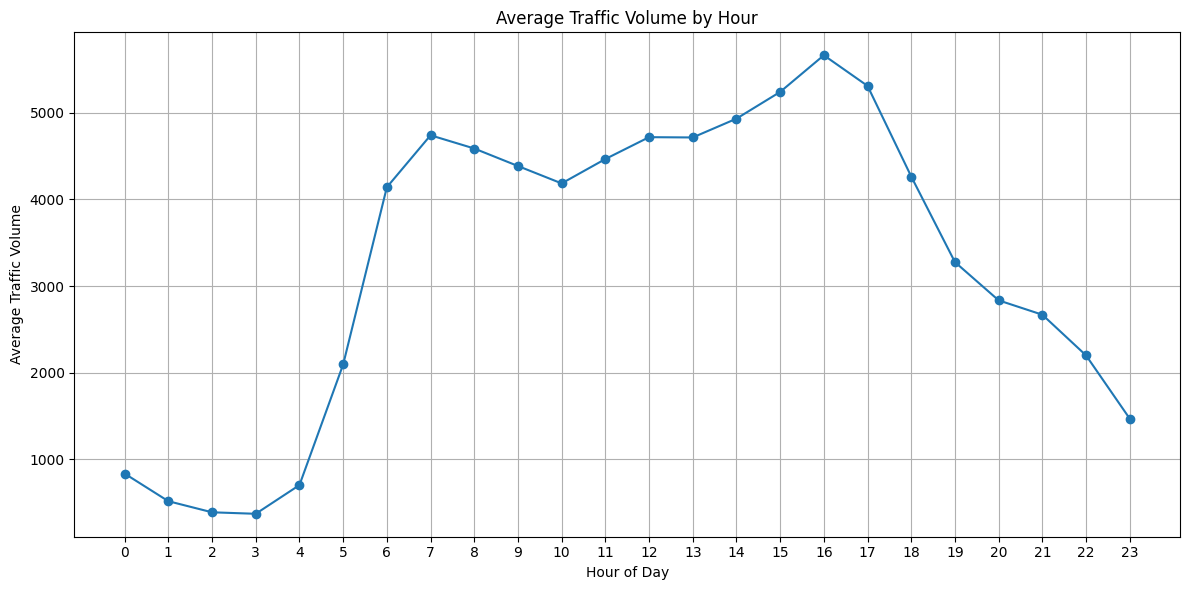


Training samples : 38563
Testing samples  : 9641

Training Linear Regression...
Linear Regression completed!

Training Random Forest Regressor...
Random Forest completed!

Training Gradient Boosting Regressor...
Gradient Boosting completed!


          REGRESSION MODEL PERFORMANCE


,Model,MAE,RMSE,R2 Score
0,Linear Regression,1547.1844,1765.3802,0.1950
1,Random Forest,310.5115,541.2118,0.9243
2,Gradient Boosting,438.7700,649.5095,0.8910


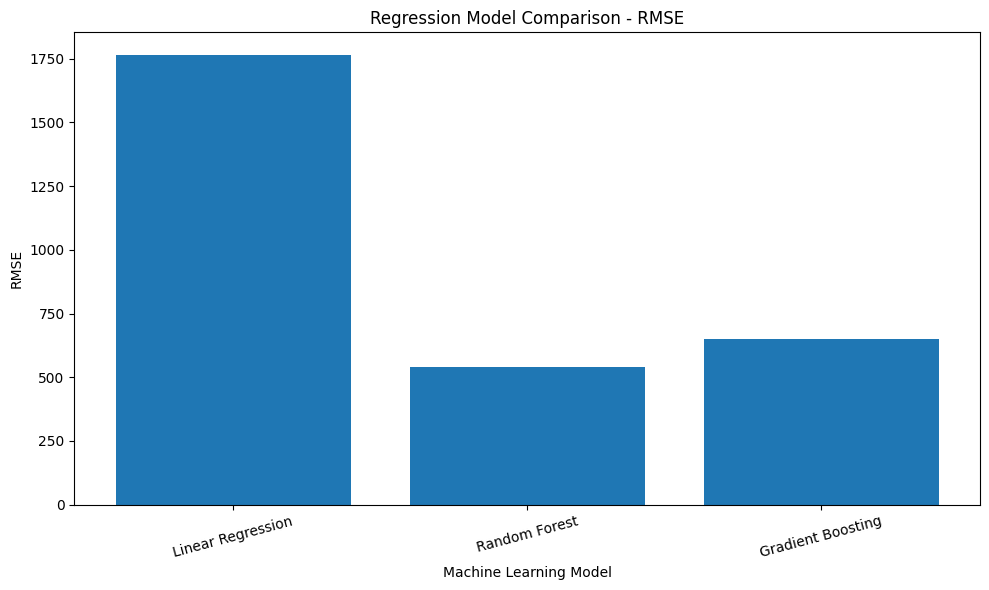


Best Regression Model: Random Forest


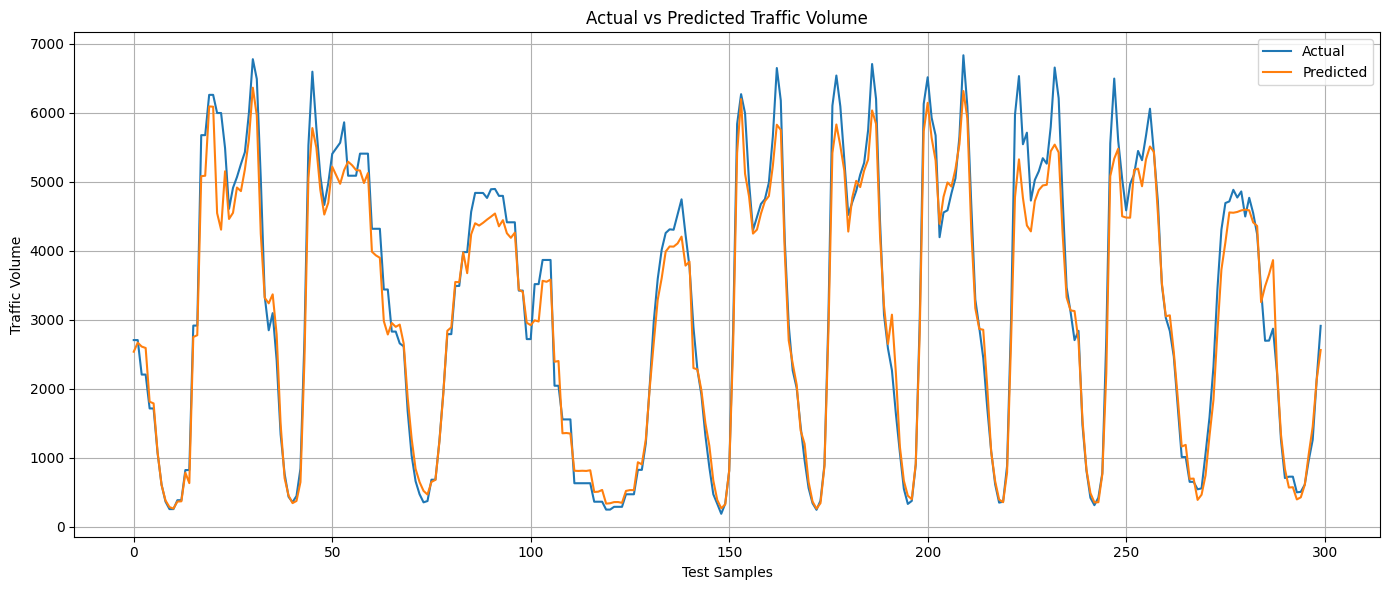


Traffic Level Thresholds
Low traffic below: 2158
Medium traffic: 2158 to 4547
High traffic above: 4547


        TRAFFIC LEVEL CLASSIFICATION ACCURACY


,Model,Accuracy
0,Linear Regression,0.4027
1,Random Forest,0.8751
2,Gradient Boosting,0.8388


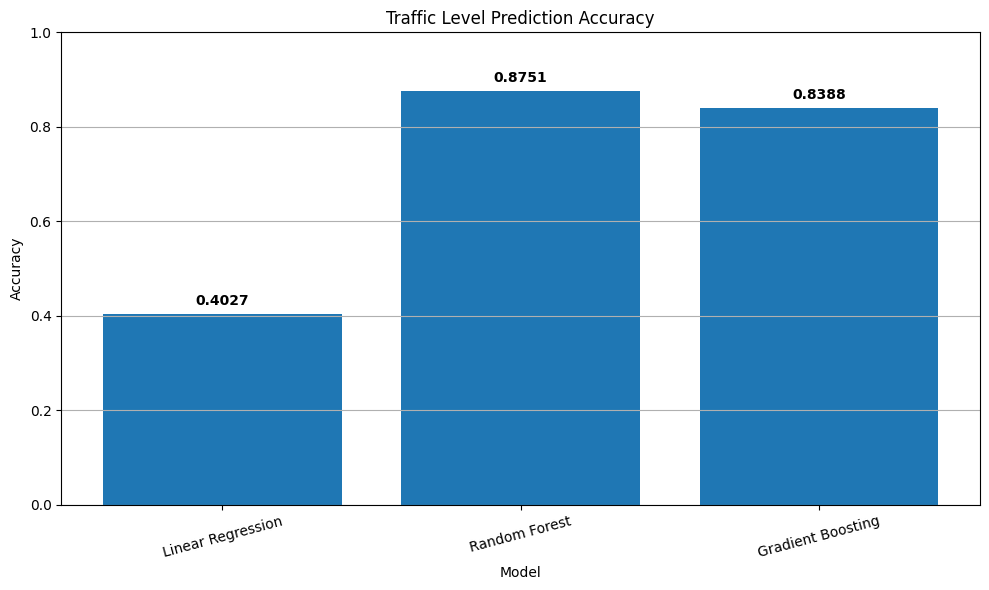

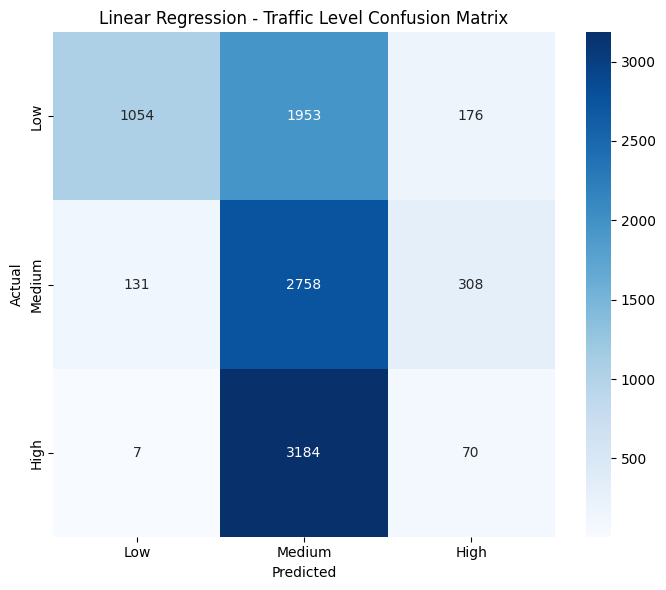

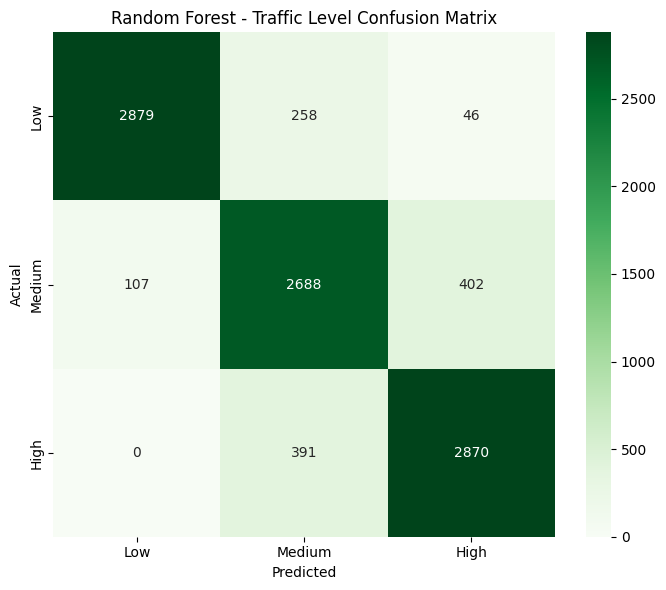

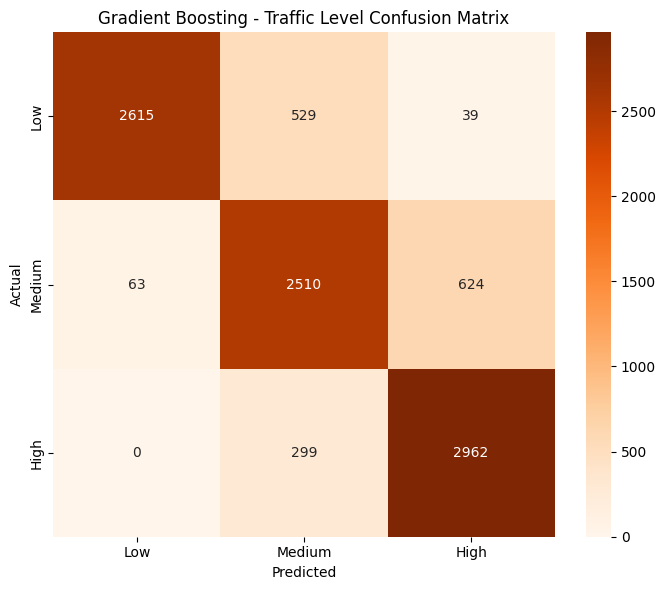



LINEAR REGRESSION - TRAFFIC LEVEL REPORT
              precision    recall  f1-score   support

         Low       0.88      0.33      0.48      3183
      Medium       0.35      0.86      0.50      3197
        High       0.13      0.02      0.04      3261

    accuracy                           0.40      9641
   macro avg       0.45      0.41      0.34      9641
weighted avg       0.45      0.40      0.34      9641



RANDOM FOREST - TRAFFIC LEVEL REPORT
              precision    recall  f1-score   support

         Low       0.96      0.90      0.93      3183
      Medium       0.81      0.84      0.82      3197
        High       0.86      0.88      0.87      3261

    accuracy                           0.88      9641
   macro avg       0.88      0.88      0.88      9641
weighted avg       0.88      0.88      0.88      9641



GRADIENT BOOSTING - TRAFFIC LEVEL REPORT
              precision    recall  f1-score   support

         Low       0.98      0.82      0.89      3183
    

In [7]:
# ================================================================
# TRAFFIC VOLUME PREDICTION USING MACHINE LEARNING
# ================================================================
# Student Name : DARSHAN D
# Register No. : RTU24101CS015
#
# Main Algorithms:
# 1. Linear Regression
# 2. Random Forest Regressor
# 3. Gradient Boosting Regressor
#
# Additional Traffic-Level Analysis:
# Low / Medium / High
# Accuracy + Confusion Matrix
# ================================================================


# ================================================================
# 1. INSTALL LIBRARIES
# ================================================================

!pip install -q ucimlrepo pandas numpy scikit-learn matplotlib seaborn joblib


# ================================================================
# 2. IMPORT LIBRARIES
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from ucimlrepo import fetch_ucirepo

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("=" * 70)
print("       TRAFFIC VOLUME PREDICTION PROJECT")
print("=" * 70)


# ================================================================
# 3. LOAD OFFICIAL UCI DATASET
# ================================================================

print("\nLoading dataset...")

dataset = fetch_ucirepo(id=492)

X_original = dataset.data.features
y_original = dataset.data.targets

df = pd.concat(
    [X_original, y_original],
    axis=1
)

print("\nDataset loaded successfully!")

print("Number of rows    :", len(df))
print("Number of columns :", len(df.columns))

print("\nFirst 5 rows:")
display(df.head())


# ================================================================
# 4. CHECK MISSING VALUES
# ================================================================

print("\n" + "=" * 70)
print("MISSING VALUE CHECK")
print("=" * 70)

print(df.isnull().sum())


# ================================================================
# 5. DATA PREPROCESSING
# ================================================================

print("\nPreprocessing data...")

# Convert date_time
df["date_time"] = pd.to_datetime(
    df["date_time"],
    errors="coerce"
)

# Remove rows where date or target is missing
df = df.dropna(
    subset=[
        "date_time",
        "traffic_volume"
    ]
)

# Extract time features

df["hour"] = df["date_time"].dt.hour

df["day_of_week"] = (
    df["date_time"].dt.dayofweek
)

df["month"] = (
    df["date_time"].dt.month
)

df["year"] = (
    df["date_time"].dt.year
)

# Weekend
df["is_weekend" ] = (
    df["day_of_week"] >= 5
).astype(int)

# Sort chronologically
df = df.sort_values(
    "date_time"
).reset_index(drop=True)

print("\nData preprocessing completed!")

print("Rows after preprocessing:", len(df))


# ================================================================
# 6. TRAFFIC VOLUME BY HOUR GRAPH
# ================================================================

hourly_traffic = (
    df.groupby("hour")["traffic_volume"]
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    hourly_traffic.index,
    hourly_traffic.values,
    marker="o"
)

plt.title(
    "Average Traffic Volume by Hour"
)

plt.xlabel("Hour of Day")

plt.ylabel(
    "Average Traffic Volume"
)

plt.xticks(range(24))

plt.grid()

plt.tight_layout()

plt.show()


# ================================================================
# 7. SELECT FEATURES
# ================================================================

features = [

    "holiday",

    "temp",

    "rain_1h",

    "snow_1h",

    "clouds_all",

    "weather_main",

    "hour",

    "day_of_week",

    "month",

    "year",

    "is_weekend"
]

target = "traffic_volume"


X = df[features]

y = df[target]


# ================================================================
# 8. NUMERICAL AND CATEGORICAL FEATURES
# ================================================================

categorical_features = [

    "holiday",

    "weather_main"
]


numerical_features = [

    "temp",

    "rain_1h",

    "snow_1h",

    "clouds_all",

    "hour",

    "day_of_week",

    "month",

    "year",

    "is_weekend"
]


# ================================================================
# 9. PREPROCESSING PIPELINE
# ================================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "numerical",

            SimpleImputer(
                strategy="median"
            ),

            numerical_features
        ),

        (
            "categorical",

            Pipeline([

                (
                    "imputer",

                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),

                (
                    "encoder",

                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )

            ]),

            categorical_features
        )
    ]
)


# ================================================================
# 10. TRAIN TEST SPLIT
# ================================================================

# 80% training
# 20% testing
#
# Data is NOT shuffled because
# traffic data is time dependent.

split_index = int(
    len(df) * 0.80
)


X_train = X.iloc[
    :split_index
]

X_test = X.iloc[
    split_index:
]


y_train = y.iloc[
    :split_index
]

y_test = y.iloc[
    split_index:
]


print("\n" + "=" * 70)

print(
    "Training samples :",
    len(X_train)
)

print(
    "Testing samples  :",
    len(X_test)
)

print("=" * 70)


# ================================================================
# 11. LINEAR REGRESSION
# ================================================================

print("\nTraining Linear Regression...")

linear_model = Pipeline([

    (
        "preprocessor",

        preprocessor
    ),

    (
        "model",

        LinearRegression()
    )
])


linear_model.fit(
    X_train,
    y_train
)


linear_prediction = (
    linear_model.predict(X_test)
)


print(
    "Linear Regression completed!"
)


# ================================================================
# 12. RANDOM FOREST REGRESSOR
# ================================================================

print(
    "\nTraining Random Forest Regressor..."
)


random_forest_model = Pipeline([

    (
        "preprocessor",

        preprocessor
    ),

    (
        "model",

        RandomForestRegressor(

            n_estimators=100,

            random_state=42,

            n_jobs=-1
        )
    )
])


random_forest_model.fit(
    X_train,
    y_train
)


random_forest_prediction = (
    random_forest_model.predict(X_test)
)


print(
    "Random Forest completed!"
)


# ================================================================
# 13. GRADIENT BOOSTING REGRESSOR
# ================================================================

print(
    "\nTraining Gradient Boosting Regressor..."
)


gradient_model = Pipeline([

    (
        "preprocessor",

        preprocessor
    ),

    (
        "model",

        GradientBoostingRegressor(

            n_estimators=100,

            learning_rate=0.05,

            max_depth=3,

            random_state=42
        )
    )
])


gradient_model.fit(
    X_train,
    y_train
)


gradient_prediction = (
    gradient_model.predict(X_test)
)


print(
    "Gradient Boosting completed!"
)


# ================================================================
# 14. REGRESSION EVALUATION
# ================================================================

def evaluate_regression(
    name,
    actual,
    predicted
):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    return [
        name,
        mae,
        rmse,
        r2
    ]


results = []


results.append(

    evaluate_regression(

        "Linear Regression",

        y_test,

        linear_prediction
    )
)


results.append(

    evaluate_regression(

        "Random Forest",

        y_test,

        random_forest_prediction
    )
)


results.append(

    evaluate_regression(

        "Gradient Boosting",

        y_test,

        gradient_prediction
    )
)


results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "MAE",

        "RMSE",

        "R2 Score"
    ]
)


# ================================================================
# 15. DISPLAY REGRESSION RESULTS
# ================================================================

print("\n")
print("=" * 70)

print(
    "          REGRESSION MODEL PERFORMANCE"
)

print("=" * 70)

display(
    results_df.round(4)
)


# ================================================================
# 16. REGRESSION MODEL COMPARISON GRAPH
# ================================================================

plt.figure(
    figsize=(10, 6)
)

plt.bar(

    results_df["Model"],

    results_df["RMSE"]
)

plt.title(
    "Regression Model Comparison - RMSE"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "RMSE"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.show()


# ================================================================
# 17. FIND BEST REGRESSION MODEL
# ================================================================

best_index = (
    results_df["RMSE"].idxmin()
)


best_model_name = (
    results_df.loc[
        best_index,
        "Model"
    ]
)


print(
    "\nBest Regression Model:",
    best_model_name
)


if best_model_name == "Linear Regression":

    best_model = linear_model

    best_prediction = (
        linear_prediction
    )


elif best_model_name == "Random Forest":

    best_model = (
        random_forest_model
    )

    best_prediction = (
        random_forest_prediction
    )


else:

    best_model = gradient_model

    best_prediction = (
        gradient_prediction
    )


# ================================================================
# 18. ACTUAL VS PREDICTED GRAPH
# ================================================================

sample = min(
    300,
    len(y_test)
)


plt.figure(
    figsize=(14, 6)
)


plt.plot(

    y_test.values[:sample],

    label="Actual"
)


plt.plot(

    best_prediction[:sample],

    label="Predicted"
)


plt.title(

    "Actual vs Predicted Traffic Volume"
)


plt.xlabel(
    "Test Samples"
)


plt.ylabel(
    "Traffic Volume"
)


plt.legend()


plt.grid()


plt.tight_layout()


plt.show()


# ================================================================
# 19. CREATE TRAFFIC LEVELS
# ================================================================
#
# To create confusion matrices, traffic volume is converted
# into three categories:
#
# LOW
# MEDIUM
# HIGH
#
# Thresholds are calculated from the TRAINING data only.
# ================================================================


low_threshold = (
    y_train.quantile(0.33)
)


high_threshold = (
    y_train.quantile(0.66)
)


print("\nTraffic Level Thresholds")

print(
    "Low traffic below:",
    round(low_threshold)
)

print(
    "Medium traffic:",
    round(low_threshold),
    "to",
    round(high_threshold)
)

print(
    "High traffic above:",
    round(high_threshold)
)


def traffic_level(value):

    if value < low_threshold:

        return "Low"

    elif value < high_threshold:

        return "Medium"

    else:

        return "High"


# Actual traffic levels
actual_levels = np.array([

    traffic_level(value)

    for value in y_test
])


# Predicted traffic levels

linear_levels = np.array([

    traffic_level(value)

    for value in linear_prediction
])


rf_levels = np.array([

    traffic_level(value)

    for value in random_forest_prediction
])


gradient_levels = np.array([

    traffic_level(value)

    for value in gradient_prediction
])


# ================================================================
# 20. CLASSIFICATION ACCURACY
# ================================================================

linear_accuracy = accuracy_score(

    actual_levels,

    linear_levels
)


rf_accuracy = accuracy_score(

    actual_levels,

    rf_levels
)


gradient_accuracy = accuracy_score(

    actual_levels,

    gradient_levels
)


accuracy_results = pd.DataFrame({

    "Model": [

        "Linear Regression",

        "Random Forest",

        "Gradient Boosting"
    ],

    "Accuracy": [

        linear_accuracy,

        rf_accuracy,

        gradient_accuracy
    ]
})


print("\n")
print("=" * 70)

print(
    "        TRAFFIC LEVEL CLASSIFICATION ACCURACY"
)

print("=" * 70)


display(
    accuracy_results.round(4)
)


# ================================================================
# 21. ACCURACY GRAPH
# ================================================================

plt.figure(
    figsize=(10, 6)
)


bars = plt.bar(

    accuracy_results["Model"],

    accuracy_results["Accuracy"]
)


plt.title(
    "Traffic Level Prediction Accuracy"
)


plt.xlabel(
    "Model"
)


plt.ylabel(
    "Accuracy"
)


plt.ylim(
    0,
    1
)


plt.xticks(
    rotation=15
)


# Display accuracy values above bars

for bar, value in zip(

    bars,

    accuracy_results["Accuracy"]

):

    plt.text(

        bar.get_x()
        + bar.get_width() / 2,

        value + 0.02,

        f"{value:.4f}",

        ha="center",

        fontweight="bold"
    )


plt.grid(
    axis="y"
)


plt.tight_layout()


plt.show()


# ================================================================
# 22. CONFUSION MATRIX - LINEAR REGRESSION
# ================================================================

cm_linear = confusion_matrix(

    actual_levels,

    linear_levels,

    labels=[
        "Low",
        "Medium",
        "High"
    ]
)


plt.figure(
    figsize=(7, 6)
)


sns.heatmap(

    cm_linear,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=[
        "Low",
        "Medium",
        "High"
    ],

    yticklabels=[
        "Low",
        "Medium",
        "High"
    ]
)


plt.title(
    "Linear Regression - Traffic Level Confusion Matrix"
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


plt.tight_layout()


plt.show()


# ================================================================
# 23. CONFUSION MATRIX - RANDOM FOREST
# ================================================================

cm_rf = confusion_matrix(

    actual_levels,

    rf_levels,

    labels=[
        "Low",
        "Medium",
        "High"
    ]
)


plt.figure(
    figsize=(7, 6)
)


sns.heatmap(

    cm_rf,

    annot=True,

    fmt="d",

    cmap="Greens",

    xticklabels=[
        "Low",
        "Medium",
        "High"
    ],

    yticklabels=[
        "Low",
        "Medium",
        "High"
    ]
)


plt.title(
    "Random Forest - Traffic Level Confusion Matrix"
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


plt.tight_layout()


plt.show()


# ================================================================
# 24. CONFUSION MATRIX - GRADIENT BOOSTING
# ================================================================

cm_gradient = confusion_matrix(

    actual_levels,

    gradient_levels,

    labels=[
        "Low",
        "Medium",
        "High"
    ]
)


plt.figure(
    figsize=(7, 6)
)


sns.heatmap(

    cm_gradient,

    annot=True,

    fmt="d",

    cmap="Oranges",

    xticklabels=[
        "Low",
        "Medium",
        "High"
    ],

    yticklabels=[
        "Low",
        "Medium",
        "High"
    ]
)


plt.title(
    "Gradient Boosting - Traffic Level Confusion Matrix"
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


plt.tight_layout()


plt.show()


# ================================================================
# 25. CLASSIFICATION REPORTS
# ================================================================

print("\n")
print("=" * 70)

print(
    "LINEAR REGRESSION - TRAFFIC LEVEL REPORT"
)

print("=" * 70)

print(

    classification_report(

        actual_levels,

        linear_levels,

        labels=[
            "Low",
            "Medium",
            "High"
        ]
    )
)


print("\n")
print("=" * 70)

print(
    "RANDOM FOREST - TRAFFIC LEVEL REPORT"
)

print("=" * 70)

print(

    classification_report(

        actual_levels,

        rf_levels,

        labels=[
            "Low",
            "Medium",
            "High"
        ]
    )
)


print("\n")
print("=" * 70)

print(
    "GRADIENT BOOSTING - TRAFFIC LEVEL REPORT"
)

print("=" * 70)

print(

    classification_report(

        actual_levels,

        gradient_levels,

        labels=[
            "Low",
            "Medium",
            "High"
        ]
    )
)


# ================================================================
# 26. BEST MODEL BASED ON TRAFFIC LEVEL ACCURACY
# ================================================================

best_accuracy_index = (
    accuracy_results["Accuracy"].idxmax()
)


best_accuracy_model = (
    accuracy_results.loc[
        best_accuracy_index,
        "Model"
    ]
)


best_accuracy_value = (
    accuracy_results.loc[
        best_accuracy_index,
        "Accuracy"
    ]
)


print("\n")
print("=" * 70)

print(
    "BEST MODEL FOR TRAFFIC LEVEL CLASSIFICATION"
)

print("=" * 70)

print(
    "Model    :",
    best_accuracy_model
)

print(
    "Accuracy :",
    f"{best_accuracy_value:.4f}"
)

print(
    "Accuracy :",
    f"{best_accuracy_value * 100:.2f}%"
)


# ================================================================
# 27. NEW TRAFFIC PREDICTION
# ================================================================

new_data = pd.DataFrame({

    "holiday": [
        "None"
    ],

    "temp": [
        288.0
    ],

    "rain_1h": [
        0.0
    ],

    "snow_1h": [
        0.0
    ],

    "clouds_all": [
        40
    ],

    "weather_main": [
        "Clear"
    ],

    "hour": [
        8
    ],

    "day_of_week": [
        0
    ],

    "month": [
        1
    ],

    "year": [
        2018
    ],

    "is_weekend": [
        0
    ]
})


new_prediction = (
    best_model.predict(new_data)
)


predicted_value = (
    new_prediction[0]
)


predicted_level = (
    traffic_level(predicted_value)
)


print("\n")
print("=" * 70)

print(
    "             NEW TRAFFIC PREDICTION"
)

print("=" * 70)

print(
    "Predicted Traffic Volume:",
    round(predicted_value),
    "vehicles/hour"
)

print(
    "Traffic Level:",
    predicted_level
)


# ================================================================
# 28. SAVE RESULTS
# ================================================================

results_df.to_csv(

    "regression_results.csv",

    index=False
)


accuracy_results.to_csv(

    "traffic_level_accuracy.csv",

    index=False
)


prediction_results = pd.DataFrame({

    "Actual Traffic Volume":
        y_test.values,

    "Predicted Traffic Volume":
        best_prediction,

    "Actual Traffic Level":
        actual_levels,

    "Predicted Traffic Level":
        np.array([
            traffic_level(v)
            for v in best_prediction
        ])
})


prediction_results.to_csv(

    "traffic_predictions.csv",

    index=False
)


joblib.dump(

    best_model,

    "traffic_volume_best_model.pkl"
)


print("\n")
print("=" * 70)

print(
    "              PROJECT COMPLETED"
)

print("=" * 70)

print(
    "Files created:"
)

print(
    "1. regression_results.csv")